# Al 6061 Printability Map Example

The following notebook demonstrates how to compute and visualize a printability map for Al 6061 using the analytical model. We will set up the process parameters, run the model to compute the defect map, and then plot the results to identify the safe processing window.

### Setup Paths and Imports

First, ensure that the notebook can access the src folder and import all the necessary modules.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Robustly find the project root by looking for the 'src' folder
current_dir = os.getcwd()
project_root = current_dir

# Move up the directory tree until we find the 'src' folder
while not os.path.isdir(os.path.join(project_root, 'src')):
    parent_dir = os.path.dirname(project_root)
    if parent_dir == project_root: # Hit the top of the file system
        raise FileNotFoundError("Could not find the 'src' directory. Are you inside the project folder?")
    project_root = parent_dir

# Add the found root to the system path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
print(f"Success! Added project root to path: {project_root}")

# Now imports will work regardless of how deep your notebook is saved
from src.data_loader import load_material
from src.physics import compute_printability_map
from src.plots import plot_deterministic_map, plot_all_zones_evolution

Success! Added project root to path: c:\Users\Ilidi\Documents\GitHub\L-PBF-Processing-Maps-Predictive-Analytical-Modelling


### Load the Material Properties
Load the thermophysical properties of Al6061 from the JSON database.

In [2]:
# Load Aluminum 6061
material_file = 'Al6061.json'
mat = load_material(material_file)
mat

print(f"Material loaded successfully: {mat['name']}")

Loading material from: c:\Users\Ilidi\Documents\GitHub\L-PBF-Processing-Maps-Predictive-Analytical-Modelling\materials\Al6061.json
Material loaded successfully: Al6061


### Define Parameters and Defect Criteria
Set up the ranges for laser power and scan speed you want to explore, as well as your fixed parameters (like hatch spacing, layer thickness, and spot size). We'll also specify which defect models to evaluate.

In [8]:
# Laser Power (W) and Scan Speed (m/s) boundaries
Power_range = (50, 350)      
Scan_Speed_range = (0.1, 2.5) 
resolution = 40 # Grid resolution (increase for a smoother plot, but will take longer)

mat['A'] = 0.25

# Fixed process parameters
# t: layer thickness, h: hatch spacing, a: spot radius, T_ambient: ambient temperature (K)
process_parameters = {
    't': 30e-6,         # 30 microns layer thickness
    'h': 100e-6,        # 100 microns hatch spacing
    'a': 50e-6,         # 25 microns spot radius
    'T_ambient': 443    # 170°C ambient temperature (preheated bed)
}

# Define active defect models to evaluate against
active_defects = {
    'balling': 'ball01',
    'lof': 'lof02',
    'keyhole': 'key01'
}

### Compute the Printability Map
Run the analytical model. This function calculates the defect mapping over the 2D parameter grid.

Computing Printability Map for Al6061. This might take a moment...
Computation complete!


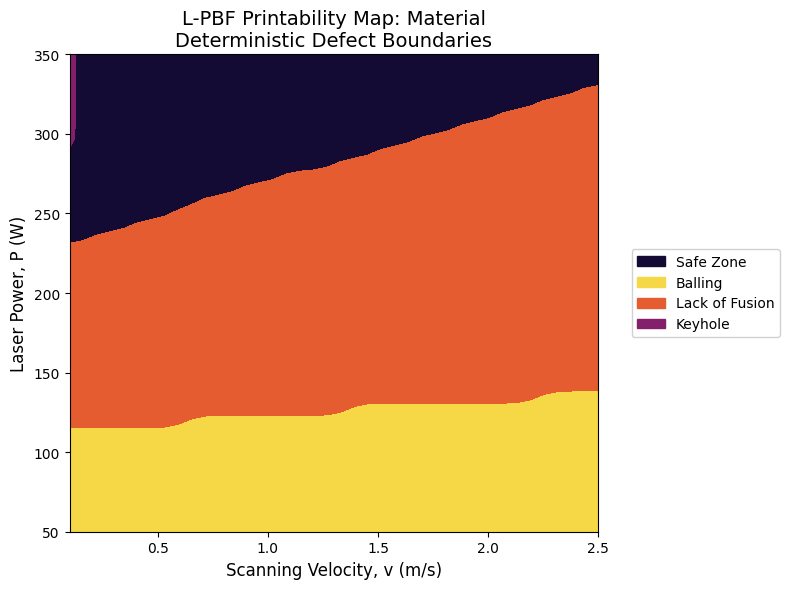

In [9]:
print("Computing Printability Map for Al6061. This might take a moment...")

P_grid, v_grid, defect_map = compute_printability_map(
    Power_range, 
    Scan_Speed_range, 
    mat, 
    process_parameters, 
    resolution=resolution, 
    active_defects=active_defects
)

print("Computation complete!")

plot_deterministic_map(P_grid, v_grid, defect_map)


plt.tight_layout()
plt.show()

### Comparing with experimental data

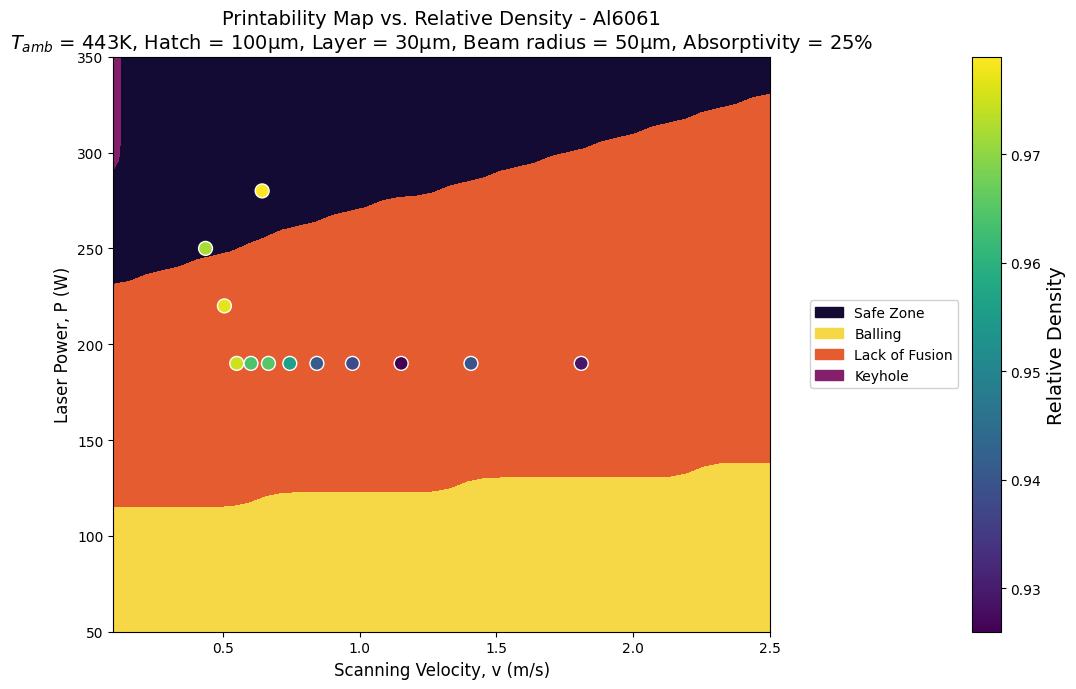

In [10]:
# 1. Load the experimental data and clean columns
exp_data = pd.read_csv('data.csv')
exp_data.columns = exp_data.columns.str.strip().str.replace("'", "")

# 2. Filter out rows that do not have a recorded relative density
density_data = exp_data.dropna(subset=['Density_relative'])

# 3. Re-create the base analytical map AND save the returned figure to 'fig'
fig = plot_deterministic_map(P_grid, v_grid, defect_map, material_name=mat['name'])
fig.set_size_inches(11, 7) 

# 4. Grab the current axis that the function just drew on
ax = plt.gca()

# 5. Scatter plot using Density_relative for color mapping
scatter = ax.scatter(density_data['v'], density_data['P'], 
                     c=density_data['Density_relative'], cmap='viridis',
                     s=100, edgecolor='white', linewidth=1, zorder=5)

# 6. Add a colorbar to interpret the density values
# Note: Because the plot is wider, you might want to reduce the pad slightly (e.g., to 0.15) 
# to bring the colorbar closer to the plot area.
cbar = plt.colorbar(scatter, ax=ax, pad=0.2)
cbar.set_label('Relative Density', fontsize=14)

# 7. Update titles and display
ax.set_title(f"Printability Map vs. Relative Density - {mat['name']}\n" 
             f"$T_{{amb}}$ = {process_parameters['T_ambient']}K, "
             f"Hatch = {process_parameters['h']*1e6:.0f}µm, "
             f"Layer = {process_parameters['t']*1e6:.0f}µm, "
             f"Beam radius = {process_parameters['a']*1e6:.0f}µm, "
             f"Absorptivity = {mat['A']*1e2:.0f}%", fontsize=14)

plt.tight_layout()
plt.show()

### 3D Safe Zone Evolution for Absorptivity

Study how the safe processing window evolves as we vary the absorptivity, which is a critical parameter for metals like aluminum.

Computing 3D Safe Zone Evolution for Absorptivity (A). This will take a while...


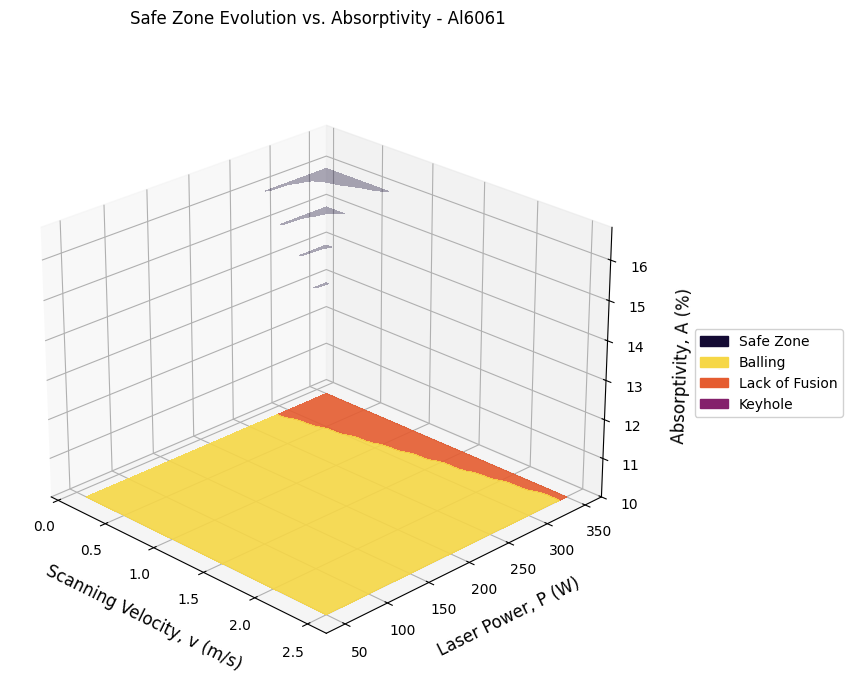

In [ ]:
from src.plots import plot_safe_zone_evolution

print("Computing 3D Safe Zone Evolution for Absorptivity (A). This will take a while...")

# Define the values of absorptivity you want to evaluate
# From the test script, we can sweep from 0.1 to 0.4
absorptivity_values = [0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2]

# Lowering resolution slightly to speed up computation for the 3D stack
stack_resolution = 35 

# Generate the 3D evolution plot
# We pass 'A' as the z_var to indicate we are sweeping absorptivity
fig_absorptivity = plot_safe_zone_evolution(
    Power_range=Power_range,
    Scan_Speed_range=Scan_Speed_range,
    material=mat,                               # Using Al6061 loaded in Cell 2
    base_process_parameters=process_parameters, # Using parameters defined in Cell 3
    z_var='A',                                  # Target variable to sweep
    z_values=absorptivity_values,
    resolution=stack_resolution,
    active_defects=active_defects
)

# Set a title and display the plot
fig_absorptivity.axes[0].set_title(f"Safe Zone Evolution vs. Absorptivity - {mat['name']}\n")
plt.show()

Computing 3D All-Zones Evolution Map for Al6061...


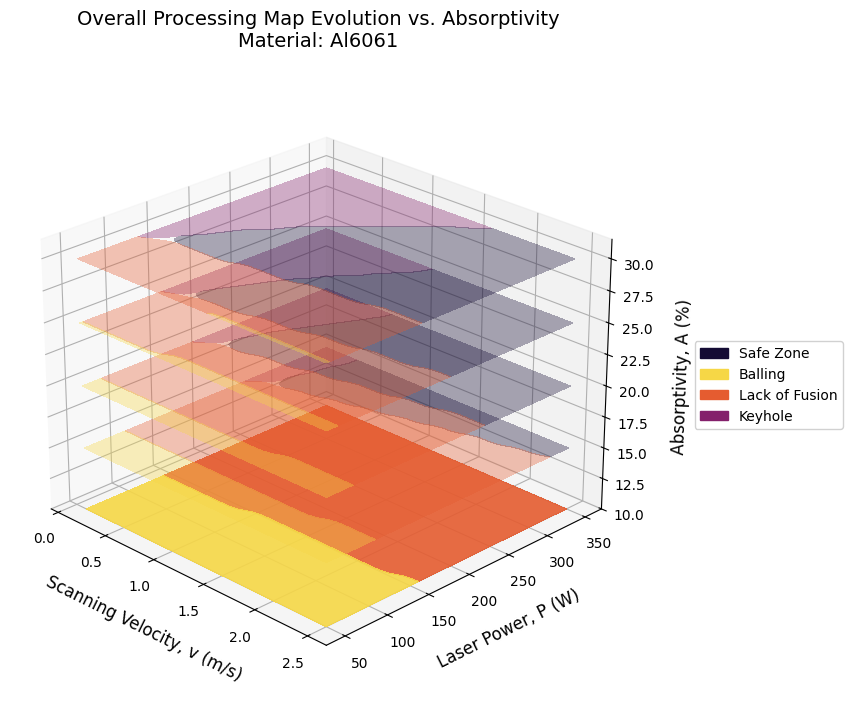

In [4]:
# 2. Define the values you want to sweep (e.g., for Absorptivity)
absorptivity_values = [0.1, 0.15, 0.2, 0.25, 0.3]

# Lowering resolution slightly to speed up computation for the 3D stack
stack_resolution = 35 

print(f"Computing 3D All-Zones Evolution Map for {mat['name']}...")

# 3. Generate the 3D evolution plot
fig_all_zones = plot_all_zones_evolution(
    Power_range=Power_range,
    Scan_Speed_range=Scan_Speed_range,
    material=mat,                               # Using Al6061 loaded earlier
    base_process_parameters=process_parameters, # Using parameters defined earlier
    z_var='A',                                  # Target variable to sweep
    z_values=absorptivity_values,
    resolution=stack_resolution,
    active_defects=active_defects
)

# Set a title and display the plot
fig_all_zones.axes[0].set_title(f"Overall Processing Map Evolution vs. Absorptivity\nMaterial: {mat['name']}\n", fontsize=14)

plt.show()